# 행렬 곱셈 단계별 추적기 - 단일 원소 계산부터 행렬 곱까지

- Tutorial ID: `ull-2`
- Tutorial: 행렬 곱셈 단계별 추적기
- Section ID: `ull-2-1`
- Section: 단일 원소 계산부터 행렬 곱까지

---

## 이 노트북에서 배우는 것

딥러닝과 트랜스포머(Transformer) 모델 안에서 일어나는 연산은, 사실 그 정체를 파헤쳐 보면 대부분 **숫자 표(행렬)를 곱하고 더하는 것**뿐입니다. "가중치를 곱한다", "어텐션 점수를 계산한다" 같은 말 뒤에는 결국 아주 단순한 산수(곱셈과 덧셈)가 아주 많이 반복되고 있을 뿐입니다.

이 노트북의 목표는 그 산수를 **칸 하나하나 직접 눈으로 따라가며** 확인하는 것입니다. 아래 순서로 진행합니다.

1. **행렬이란 무엇인지**, 그리고 두 행렬을 곱하려면 어떤 조건이 필요한지 알아봅니다.
2. 결과 행렬의 칸(원소) **딱 하나만** 계산하는 과정을 손으로 풀어보듯 추적합니다.
3. 그 과정을 **모든 칸에 반복**해서 전체 행렬 곱셈을 완성합니다.
4. 같은 원리가 트랜스포머의 **어텐션(Attention) 점수 계산**에 그대로 쓰인다는 것을 확인합니다.
5. 행렬 곱셈 한 번에 곱셈·덧셈이 몇 번 일어나는지(**FLOPS**) 세어 보고, 이것이 왜 모델 속도/비용과 관련 있는지 감을 잡습니다.

> 💡 **읽는 법**: 코드를 먼저 읽지 말고, 코드 *위*에 있는 설명 글을 먼저 읽어주세요. 그런 다음 코드를 실행하고, 출력된 숫자를 설명과 하나씩 맞춰보면서 "아, 이래서 이 숫자가 나오는구나"를 확인하는 순서로 보면 가장 이해가 잘 됩니다.
>
> 이 노트북은 numpy와 matplotlib만 사용하므로 별도 설치 없이(또는 `pip install numpy matplotlib`만으로) 어디서든 바로 실행할 수 있습니다.


In [1]:
# ============================================================
# 코드 읽는 법 — 단일 원소 계산부터 행렬 곱까지
#
# 이 코드는 "정답을 한 번 실행해서 결과만 보는" 용도가 아니라,
# "행렬 곱셈"이라는 수학 개념이 실제로 어떤 숫자 연산으로 풀어지는지
# 한 줄, 한 칸씩 추적하기 위한 실습 노트입니다.
#
# 학습 목표:
#   1) 행렬 곱셈 C = A @ B 에서, 결과의 칸 하나(C[i, j])가
#      "A의 한 행"과 "B의 한 열"을 곱하고 더한 값이라는 것을 직접 확인한다.
#   2) 이 과정을 모든 칸에 반복하면 행렬 전체가 채워진다는 것을 이해한다.
#   3) 같은 원리가 트랜스포머의 어텐션 점수 계산(Q·K^T)에도 그대로
#      쓰인다는 것을 확인한다.
#   4) 행렬 곱셈 한 번에 곱셈·덧셈이 몇 번 일어나는지(FLOPS) 세어 보고,
#      모델 크기나 문장 길이가 커지면 연산량이 어떻게 늘어나는지 감을 잡는다.
#
# 읽는 순서 (각 섹션은 "설명(마크다운) -> 코드 -> 결과" 순서로 이어집니다):
#   0) 행렬이 무엇인지, 두 행렬을 곱할 수 있는 조건은 무엇인지 먼저 확인합니다.
#   1) 아주 작은 두 행렬 A(2x3), B(3x2)를 만들고, 결과 칸 C[0,0] 하나만
#      손으로 계산하듯 단계별로 추적합니다.
#   2) 같은 계산을 반복문으로 모든 칸에 적용해서 행렬 전체 C를 완성하고,
#      numpy의 A @ B 결과와 같은지 검증합니다.
#   3) 같은 "행·열 내적" 패턴이 트랜스포머의 어텐션 점수 계산에도
#      그대로 등장하는 것을 확인합니다. (Q, K라는 새 용어는 해당
#      섹션에서 비유를 들어 먼저 설명한 뒤 코드를 봅니다.)
#   4) seed, 행렬 크기, d_head, seq_len 등 숫자를 직접 바꿔보면서
#      결과가 어떻게 달라지는지 실험해 봅니다.
#
# 주의:
#   - 숫자 하나하나를 외우려 하지 말고, "어떤 숫자끼리 곱해지고 더해지는지"와
#     "행렬의 모양(shape)이 어떻게 바뀌는지"의 흐름을 눈으로 따라가 보세요.
#   - 이 노트북은 numpy/matplotlib만 사용하므로 로컬 환경, Jupyter,
#     Google Colab 어디서든 그대로 실행됩니다.
# ============================================================


In [2]:
# numpy: 행렬(2차원 숫자 표) 연산을 빠르고 간편하게 해 주는 라이브러리입니다.
#        이 노트북에서는 행렬을 만들고(np.array), 곱하고(@), 합하는 데 사용합니다.
import numpy as np

# matplotlib: 숫자 표를 색깔이 있는 그림(히트맵)으로 그려서
#             "큰 수는 진하게, 작은 수는 연하게" 한눈에 보기 위해 사용합니다.
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 그래프 안의 한글(제목, 축 이름 등)이 네모 박스로 깨지지 않도록,
# 컴퓨터에 설치된 한글 폰트를 자동으로 찾아서 사용합니다.
# 아래 후보 중 하나라도 설치되어 있으면 그 폰트를 쓰고, 하나도 없으면
# 그냥 기본 폰트로 넘어갑니다(이 경우 그래프의 한글 글자만 깨질 뿐,
# 숫자나 그래프 모양, 코드 실행 자체에는 전혀 영향이 없습니다).
# (Google Colab에서 한글이 깨진다면 `!apt-get -qq install fonts-nanum`을
#  실행한 뒤 런타임을 다시 시작하면 해결됩니다.)
_korean_font_candidates = ["NanumGothic", "Malgun Gothic", "AppleGothic", "Apple SD Gothic Neo", "NanumBarunGothic"]
_installed_fonts = {f.name for f in fm.fontManager.ttflist}
for _font_name in _korean_font_candidates:
    if _font_name in _installed_fonts:
        plt.rcParams["font.family"] = _font_name
        break
plt.rcParams["axes.unicode_minus"] = False  # 한글 폰트 사용 시 마이너스(-) 기호가 깨지는 문제 방지

print("=" * 62)
print("행렬 곱셈 단계별 추적")
print("=" * 62)


행렬 곱셈 단계별 추적


## 0. 준비 운동 — 행렬이란 무엇인가?

**행렬(matrix)**은 숫자를 직사각형 모양으로 줄 세워 놓은 표일 뿐입니다. 학교 성적표를 떠올려 보면 쉽습니다.

| | 국어 | 수학 |
|---|---|---|
| 철수 | 90 | 80 |
| 영희 | 70 | 100 |

이 표를 행렬로 쓰면 다음과 같습니다.

```
[[90, 80],
 [70, 100]]
```

- **행(row)**: 가로 한 줄. 위 표에서는 "철수의 점수"(90, 80), "영희의 점수"(70, 100)가 각각 하나의 행입니다.
- **열(column)**: 세로 한 줄. "국어 점수"(90, 70), "수학 점수"(80, 100)가 각각 하나의 열입니다.
- **shape(모양)**: "몇 행 × 몇 열"인지를 나타냅니다. 위 표는 학생 2명 × 과목 2개이므로 **(2, 2)** 행렬입니다.

행렬 안의 특정 칸을 가리킬 때는 `A[i, j]`라고 씁니다. 여기서 **i는 몇 번째 행인지, j는 몇 번째 열인지**를 뜻합니다.

> ⚠️ **파이썬/numpy는 0부터 센다는 점에 주의하세요.** 첫 번째 행은 `0번 행`, 두 번째 행은 `1번 행`입니다. 위 표에서 철수의 수학 점수(80)는 "0번 행, 1번 열"이므로 `A[0, 1]`로 접근합니다. 사람이 흔히 세는 "1번째, 2번째"보다 하나씩 작은 번호를 쓴다는 점을 꼭 기억해 두세요.

아래 코드에서 위 성적표를 실제로 numpy 행렬로 만들어 shape와 인덱싱을 확인해 봅니다.


In [3]:
# 위 성적표를 그대로 numpy 행렬로 만들어 봅니다.
#   행(row)    : 학생 한 명 -> [국어 점수, 수학 점수]
#   열(column) : 과목 하나  -> 모든 학생의 해당 과목 점수를 세로로 모은 것
scores = np.array([
    [90, 80],   # 0번 행: 철수의 [국어, 수학] 점수
    [70, 100],  # 1번 행: 영희의 [국어, 수학] 점수
])

print(f"scores 행렬:\n{scores}")
print(f"\nshape(모양) = {scores.shape}  ->  {scores.shape[0]}행 × {scores.shape[1]}열")

# 인덱싱 연습: A[i, j] = i번째 행, j번째 열
print(f"\nscores[0, 0] = {scores[0, 0]}  (0번 행=철수, 0번 열=국어 -> 철수의 국어 점수)")
print(f"scores[0, 1] = {scores[0, 1]}  (0번 행=철수, 1번 열=수학 -> 철수의 수학 점수)")
print(f"scores[1, 0] = {scores[1, 0]}  (1번 행=영희, 0번 열=국어 -> 영희의 국어 점수)")
print(f"scores[1, 1] = {scores[1, 1]}  (1번 행=영희, 1번 열=수학 -> 영희의 수학 점수)")

# 행 전체 / 열 전체를 한 번에 꺼낼 수도 있습니다.
print(f"\nscores[0, :] = {scores[0, :]}  (0번 행 전체 = 철수의 모든 점수)")
print(f"scores[:, 1] = {scores[:, 1]}  (1번 열 전체 = 모든 학생의 수학 점수)")


scores 행렬:
[[ 90  80]
 [ 70 100]]

shape(모양) = (2, 2)  ->  2행 × 2열

scores[0, 0] = 90  (0번 행=철수, 0번 열=국어 -> 철수의 국어 점수)
scores[0, 1] = 80  (0번 행=철수, 1번 열=수학 -> 철수의 수학 점수)
scores[1, 0] = 70  (1번 행=영희, 0번 열=국어 -> 영희의 국어 점수)
scores[1, 1] = 100  (1번 행=영희, 1번 열=수학 -> 영희의 수학 점수)

scores[0, :] = [90 80]  (0번 행 전체 = 철수의 모든 점수)
scores[:, 1] = [ 80 100]  (1번 열 전체 = 모든 학생의 수학 점수)


## 0-1. 두 행렬은 언제 곱할 수 있을까?

행렬 곱셈은 그냥 "같은 자리에 있는 숫자끼리 곱하는" 연산이 아닙니다. (그런 연산도 따로 있지만, 행렬 곱셈과는 다릅니다.) 행렬 곱셈 `C = A @ B`는 **"A의 한 행"과 "B의 한 열"을 짝지어 내적(자리별로 곱한 뒤 모두 더하기)**하는 연산입니다.

이렇게 "행과 열을 짝짓는" 연산이다 보니, 아무 두 행렬이나 곱할 수 있는 게 아니라 조건이 있습니다.

> **A가 (m, n) 행렬이고 B가 (n, p) 행렬일 때만 곱셈 A @ B가 가능하며, 결과는 (m, p) 행렬이 됩니다.**
> 즉, **A의 열 개수(n)와 B의 행 개수(n)가 반드시 같아야** 합니다.

왜 그래야 할까요? 장바구니로 비유해 보겠습니다. 사과·바나나·우유 3가지를 산다고 할 때,

- 수량: `[사과 2개, 바나나 3개, 우유 1개]` (숫자 3개)
- 가격: `[사과 1000원, 바나나 500원, 우유 2500원]` (숫자 3개)

총 가격은 `2×1000 + 3×500 + 1×2500`처럼 **수량과 가격을 자리별로 짝지어 곱한 뒤 모두 더해서** 구합니다. 이게 바로 내적(dot product)이고, 행렬 곱셈 결과의 칸 하나하나가 정확히 이 계산입니다.

그런데 만약 가격 목록에 "감자 가격"까지 4개가 들어 있다면, 수량은 3개뿐이라 감자 가격과 짝지을 수량이 없습니다. 바로 이런 상황을 막기 위해 "A의 열 개수 = B의 행 개수"라는 조건이 필요합니다. **A의 한 행(길이 n)과 B의 한 열(길이 n)은 길이가 같아야 빠짐없이 짝지어 곱하고 더할 수 있습니다.**

아래 코드에서 조건에 맞는 경우와 맞지 않는 경우를 직접 비교해 봅니다.


In [4]:
# 조건에 맞는 예: A가 (2,3), B가 (3,2) -> A의 열(3) == B의 행(3) -> 곱셈 가능, 결과는 (2,2)
A_demo = np.zeros((2, 3))
B_demo = np.zeros((3, 2))
C_demo = A_demo @ B_demo
print(f"A.shape={A_demo.shape}, B.shape={B_demo.shape}  ->  곱셈 가능! 결과 shape={C_demo.shape}")

# 조건에 맞지 않는 예: A가 (2,3), B가 (4,2) -> A의 열(3) != B의 행(4) -> 곱셈 불가능
A_bad = np.zeros((2, 3))
B_bad = np.zeros((4, 2))
print(f"\nA.shape={A_bad.shape}, B.shape={B_bad.shape}  ->  A의 열(3) != B의 행(4) 이므로...")
try:
    A_bad @ B_bad
except ValueError as e:
    print(f"  실제로 에러 발생: {e}")
    print("  (numpy도 우리와 똑같은 이유로 곱셈을 거부하는 것을 볼 수 있습니다)")


A.shape=(2, 3), B.shape=(3, 2)  ->  곱셈 가능! 결과 shape=(2, 2)

A.shape=(2, 3), B.shape=(4, 2)  ->  A의 열(3) != B의 행(4) 이므로...
  실제로 에러 발생: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 4 is different from 3)
  (numpy도 우리와 똑같은 이유로 곱셈을 거부하는 것을 볼 수 있습니다)


## 1. 결과 행렬의 칸 하나만 계산해보기 — C[0, 0] 추적

이제 실제로 두 행렬 A(2×3), B(3×2)를 만들고, 그 곱 `C = A @ B`의 **첫 번째 칸 C[0, 0]** 하나만 손으로 풀듯이 계산해 보겠습니다.

규칙은 단순합니다.

> **C[i, j] = (A의 i번째 행)과 (B의 j번째 열)을 자리별로 곱한 뒤, 모두 더한 값**

그러니 `C[0, 0]`을 구하려면,

1. A의 **0번째 행** 전체를 가져오고
2. B의 **0번째 열** 전체를 가져온 다음
3. 두 줄을 같은 자리(0번째끼리, 1번째끼리, 2번째끼리...)로 곱하고
4. 그 곱한 값들을 모두 더하면 됩니다.

아래 코드는 이 4단계를 `for` 반복문으로 한 단계씩 출력하면서 진행합니다. 반복문 안의 변수 `k`는 "지금 몇 번째 자리를 곱하고 있는지"를 나타내는 인덱스이고, `accumulator`(누산기)는 "지금까지 더한 값"을 계속 누적해서 저장하는 변수입니다.


In [5]:
print("\n1. 단일 원소 C[0,0] 계산 추적")
print("-" * 50)

# A: 2행 3열 행렬 (2x3)
A = np.array([[1, 2, 3],
              [4, 5, 6]])

# B: 3행 2열 행렬 (3x2)
# A의 열 개수(3)와 B의 행 개수(3)가 같으므로 A @ B 가 가능합니다 (바로 위에서 배운 조건!)
B = np.array([[7, 8],
              [9, 10],
              [11, 12]])

print(f"A (2×3):\n{A}")
print(f"\nB (3×2):\n{B}")
print(f"\nC = A @ B 는 (2×2) 행렬이 됩니다 (A의 행 개수 2, B의 열 개수 2).")

# C[i, j]를 구할 행/열 번호를 지정합니다. 여기서는 첫 번째 칸인 (0, 0)을 계산합니다.
i, j = 0, 0
print(f"\n  C[{i},{j}] = ", end="")

accumulator = 0   # "지금까지 곱해서 더한 값"을 차곡차곡 쌓아갈 누산기. 시작은 0.
steps = []        # 화면에 보여줄 계산 과정(문자열)을 차곡차곡 모아둘 리스트.

# A.shape[1] = A의 열 개수 = 3. k는 0, 1, 2 순서로 움직이며
# "A의 i번째 행에서 k번째 칸"과 "B의 j번째 열에서 k번째 칸"을 짝지어 봅니다.
for k in range(A.shape[1]):
    product = A[i, k] * B[k, j]      # 같은 자리(k번째)끼리 곱하기
    accumulator += product            # 누산기에 더해서 쌓기
    steps.append(f"A[{i},{k}]×B[{k},{j}] = {A[i,k]}×{B[k,j]} = {product}")

# 곱셈 수식 한 줄 보여주기: 1×7 + 2×9 + 3×11 형태
print(" + ".join(f"{A[i,k]}×{B[k,j]}" for k in range(A.shape[1])))
for step in steps:
    print(f"         {step}")
print(f"         = {accumulator}")

print(f"\n  검증: A의 0번 행 {A[i, :]} 와 B의 0번 열 {B[:, j]} 을 내적(np.dot)하면 -> {np.dot(A[i, :], B[:, j])}")



1. 단일 원소 C[0,0] 계산 추적
--------------------------------------------------
A (2×3):
[[1 2 3]
 [4 5 6]]

B (3×2):
[[ 7  8]
 [ 9 10]
 [11 12]]

C = A @ B 는 (2×2) 행렬이 됩니다 (A의 행 개수 2, B의 열 개수 2).

  C[0,0] = 1×7 + 2×9 + 3×11
         A[0,0]×B[0,0] = 1×7 = 7
         A[0,1]×B[1,0] = 2×9 = 18
         A[0,2]×B[2,0] = 3×11 = 33
         = 58

  검증: A의 0번 행 [1 2 3] 와 B의 0번 열 [ 7  9 11] 을 내적(np.dot)하면 -> 58


## 2. 전체 행렬 곱 추적 — 모든 칸에 같은 과정을 반복하기

방금 `C[0, 0]` 하나를 구하는 법을 배웠습니다. C는 (2×2) 행렬이므로 채워야 할 칸이 `C[0,0]`, `C[0,1]`, `C[1,0]`, `C[1,1]` 이렇게 4개 있습니다. **방법은 모두 똑같습니다** — "A의 i번째 행"과 "B의 j번째 열"을 내적하면 됩니다. 앞에서 한 번 했던 계산을 **i와 j를 바꿔가며 반복**하기만 하면 행렬 전체가 완성됩니다.

코드에서는 이를 위해 `for i ...` 바깥 반복문과 `for j ...` 안쪽 반복문, 그리고 그 안에 다시 `for k ...` 반복문, 이렇게 **3중 반복문**을 사용합니다.

- 바깥 `i` 반복문: 결과 행렬의 **행**을 하나씩 이동
- 중간 `j` 반복문: 결과 행렬의 **열**을 하나씩 이동
- 가장 안쪽 `k` 반복문: 그 칸 하나를 채우기 위한 **내적 계산** (앞 섹션에서 했던 것과 동일)

또 한 가지, 코드에 등장하는 **MAC(Multiply-Accumulate, 곱셈-누산)**이라는 용어도 짚고 넘어가겠습니다. `product = A[i,k] * B[k,j]`처럼 **한 번 곱하고, 그 결과를 누산기에 더하는 동작 한 쌍**을 1 MAC 연산이라고 부릅니다. 1 MAC = 곱셈 1번 + 덧셈 1번 = **부동소수점 연산(FLOPs) 2번**입니다. 이 MAC 횟수를 세어 두면, 나중에 "이 행렬 곱셈에 연산이 총 몇 번 필요한가"를 계산하는 데 그대로 쓸 수 있습니다 (마지막 섹션에서 이 개념을 다시 사용합니다).

아래 코드를 실행하면 4개의 칸이 각각 어떤 곱셈/덧셈으로 채워지는지 모두 출력되고, 마지막에는 numpy의 `A @ B`와 결과가 정확히 같은지 `np.allclose`로 검증합니다.


In [6]:
print("\n2. 전체 행렬 곱 추적")
print("-" * 50)

C = np.zeros((A.shape[0], B.shape[1]))  # 결과를 담을 그릇을 미리 0으로 채워서 준비 (shape: 2x2)
total_macs = 0  # 지금까지 수행한 MAC(곱셈+누산) 횟수를 셀 변수

# 바깥 반복문: 결과 행렬의 "행" 번호 i를 0부터 (A의 행 개수 - 1)까지 이동
for i in range(A.shape[0]):
    # 중간 반복문: 결과 행렬의 "열" 번호 j를 0부터 (B의 열 개수 - 1)까지 이동
    for j in range(B.shape[1]):
        print(f"\n  C[{i},{j}]:", end=" ")
        acc = 0       # 이 칸(C[i,j]) 하나를 채우기 위한 누산기
        terms = []    # 화면 출력을 위해 "숫자×숫자" 형태의 항들을 모아두는 리스트

        # 가장 안쪽 반복문: 1번 섹션에서 했던 것과 똑같은 내적 계산
        for k in range(A.shape[1]):
            product = A[i, k] * B[k, j]
            acc += product
            total_macs += 1   # 곱셈 한 번 + 누산 한 번 = MAC 1회 카운트
            terms.append(f"{A[i,k]}×{B[k,j]}")

        C[i, j] = acc   # 다 더한 값을 결과 행렬의 (i, j) 칸에 저장
        print(f"{' + '.join(terms)} = {acc}")

print(f"\n  결과 C:\n{C.astype(int)}")
print(f"\n  검증: np.allclose = {np.allclose(C, A @ B)}")
print("  (직접 반복문으로 계산한 C와, numpy가 한 줄 'A @ B'로 계산한 결과가 완전히 같다는 뜻입니다)")
print(f"\n  총 MAC 연산: {total_macs}  (= '결과 칸 개수(2×2)' × '내적 한 번의 곱셈 횟수(3)')")
print(f"  총 FLOPS: {total_macs * 2}  (MAC 1회 = 곱셈 1번 + 덧셈 1번 = FLOPs 2번)")



2. 전체 행렬 곱 추적
--------------------------------------------------

  C[0,0]: 1×7 + 2×9 + 3×11 = 58

  C[0,1]: 1×8 + 2×10 + 3×12 = 64

  C[1,0]: 4×7 + 5×9 + 6×11 = 139

  C[1,1]: 4×8 + 5×10 + 6×12 = 154

  결과 C:
[[ 58  64]
 [139 154]]

  검증: np.allclose = True
  (직접 반복문으로 계산한 C와, numpy가 한 줄 'A @ B'로 계산한 결과가 완전히 같다는 뜻입니다)

  총 MAC 연산: 12  (= '결과 칸 개수(2×2)' × '내적 한 번의 곱셈 횟수(3)')
  총 FLOPS: 24  (MAC 1회 = 곱셈 1번 + 덧셈 1번 = FLOPs 2번)


### 잠깐, 그림으로도 확인해 볼까요?

숫자만 보면 헷갈릴 수 있으니, A·B·C를 색깔이 있는 표(히트맵)로 한 번 그려보겠습니다. **숫자가 클수록 진한 색, 작을수록 연한 색**으로 표시됩니다. 빨간 테두리는 "A의 0번 행"과 "B의 0번 열"이 만나 "C[0,0]"이 되는 모습을 표시한 것입니다. 그림으로 보면 행과 열이 만나는 느낌을 더 직관적으로 잡을 수 있습니다.


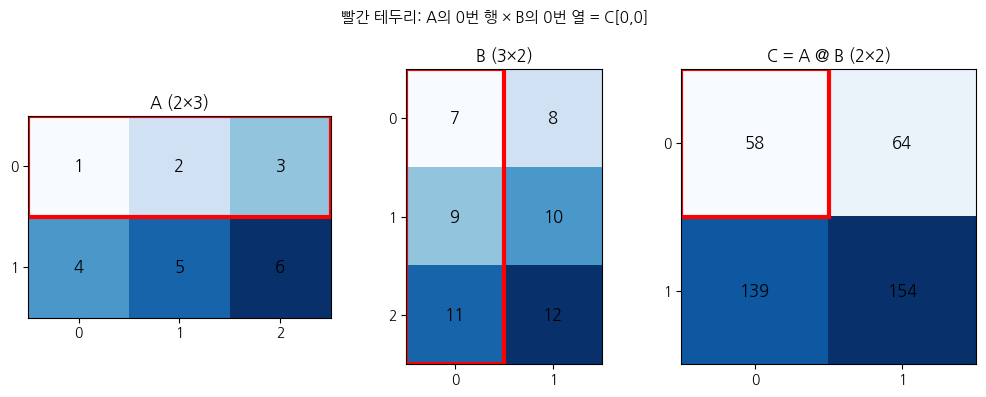

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

matrices = [A, B, C.astype(int)]
titles = ["A (2×3)", "B (3×2)", "C = A @ B (2×2)"]

for ax, M, title in zip(axes, matrices, titles):
    ax.imshow(M, cmap="Blues")
    ax.set_title(title)
    # 각 칸 위에 실제 숫자 값을 글씨로 적기
    for (r, c), val in np.ndenumerate(M):
        ax.text(c, r, str(val), ha="center", va="center", fontsize=12)
    ax.set_xticks(range(M.shape[1]))
    ax.set_yticks(range(M.shape[0]))

# A의 0번 행, B의 0번 열, C의 (0,0) 칸을 빨간 테두리로 강조
axes[0].add_patch(plt.Rectangle((-0.5, -0.5), 3, 1, fill=False, edgecolor="red", linewidth=3))
axes[1].add_patch(plt.Rectangle((-0.5, -0.5), 1, 3, fill=False, edgecolor="red", linewidth=3))
axes[2].add_patch(plt.Rectangle((-0.5, -0.5), 1, 1, fill=False, edgecolor="red", linewidth=3))

plt.suptitle("빨간 테두리: A의 0번 행 × B의 0번 열 = C[0,0]", fontsize=11)
plt.tight_layout()
plt.show()


## 3. 행렬 곱셈은 실제로 어디에 쓰일까? — 트랜스포머의 어텐션(Attention)

지금까지 본 것처럼 행렬 곱셈은 "행과 열을 내적하는 것"의 반복일 뿐입니다. 그런데 이 단순한 연산이 ChatGPT 같은 거대 언어모델(LLM)의 핵심 동작에도 **그대로** 쓰입니다. 신경망의 거의 모든 레이어는 "입력 벡터 @ 가중치 행렬" 형태의 행렬 곱셈이고, 트랜스포머의 **셀프 어텐션(Self-Attention)**도 예외가 아닙니다.

어텐션을 아주 간단히 비유하면 **도서관에서 책 찾기**와 비슷합니다.

- 당신이 사서에게 "이런 내용의 책을 찾고 있어요"라고 말합니다. 이 "찾고 있는 것"을 **Query(질의, Q)**라고 부릅니다.
- 도서관의 책마다 "이 책은 이런 내용을 담고 있어요"라는 색인 카드가 붙어 있습니다. 이 "내가 가진 정보"를 **Key(색인, K)**라고 부릅니다.
- 당신의 Query와 각 책의 Key를 비교해서, **얼마나 잘 맞는지 점수**를 매깁니다. 점수가 높을수록 "지금 더 주의(attention)를 기울여야 할 책"이라는 뜻입니다.

트랜스포머에서는 문장의 각 단어(토큰)마다 Query 벡터와 Key 벡터가 (학습된 가중치 행렬을 통해) 만들어집니다. 그리고 **점수 = Query와 Key를 내적한 값**으로 계산합니다 — 네, 우리가 방금 배운 "행과 열을 곱하고 더하는" 바로 그 연산입니다! 단어 i의 Query와 단어 j의 Key를 내적하면 "단어 i가 단어 j를 얼마나 주의 깊게 봐야 하는지"에 대한 점수가 나옵니다.

이 노트북에서는 두 가지 후처리를 더 거칩니다.

1. **스케일링 (값을 sqrt(d_head)로 나누기)**: Query·Key의 차원 수(d_head)가 커지면 내적 값도 따라서 커지는 경향이 있습니다. 값이 너무 커지면 다음 단계인 소프트맥스가 불안정해지므로, 차원 수의 제곱근으로 나누어 적당한 크기로 줄여줍니다.
2. **소프트맥스 (softmax)**: 점수를 그대로 쓰지 않고, **합이 1이 되는 비율(확률처럼 보이는 가중치)**로 바꿔줍니다. 점수가 높은 단어는 비율도 높아지고, 낮은 단어는 비율도 낮아집니다. 이렇게 만든 "비율"이 바로 **어텐션 가중치(attention weight)**이고, "이 단어를 만들 때 다른 단어들을 각각 몇 %씩 참고할지"를 나타냅니다.

아래 코드는 아주 작은 예시(단어 2개, 차원 3)로 이 과정을 한 단계씩 그대로 추적합니다.


In [8]:
print("\n\n3. 어텐션 점수 Q·K^T 계산 추적")
print("-" * 50)

d_head = 3   # Query/Key 벡터 하나의 차원 수 (숫자가 몇 개씩 들어있는지)
seq_len = 2  # 문장(시퀀스) 안의 토큰(단어) 개수 -> 여기서는 단어 2개짜리 아주 짧은 문장

np.random.seed(42)  # 매번 같은 "랜덤" 숫자가 나오도록 고정 (재현 가능하게 하기 위함)
# 실제 트랜스포머에서는 Q, K가 학습된 가중치로 계산되지만,
# 여기서는 계산 과정만 보기 위해 임의의 숫자로 대신합니다.
Q = np.round(np.random.randn(seq_len, d_head), 2)  # shape: (2, 3) -> 토큰 2개 x 차원 3
K = np.round(np.random.randn(seq_len, d_head), 2)  # shape: (2, 3) -> 토큰 2개 x 차원 3

print(f"Q (query) - 토큰마다 '내가 찾는 것'을 나타내는 벡터:\n{Q}")
print(f"\nK (key) - 토큰마다 '내가 가진 정보'를 나타내는 벡터:\n{K}")
print(f"\nscale = 1/sqrt(d_head) = 1/sqrt({d_head}) = {1/np.sqrt(d_head):.4f}")
print("(차원 수가 커지면 내적 값도 커지는 경향이 있어, 이 값을 곱해(=sqrt(d_head)로 나누어) 적당한 크기로 줄여줍니다)")

scores = np.zeros((seq_len, seq_len))  # 결과: (토큰 개수 x 토큰 개수) 점수표

# i: Query 토큰 번호 (지금 "찾는 중"인 토큰), j: Key 토큰 번호 (비교 대상이 되는 토큰)
for i in range(seq_len):
    for j in range(seq_len):
        dot = 0
        print(f"\n  score[q{i},k{j}] = Q[{i}]·K[{j}] / sqrt({d_head})")
        terms = []

        # d_head(=3)개의 자리를 하나씩 곱해서 더하기 -> 이것도 결국 "내적"입니다
        for k in range(d_head):
            prod = Q[i, k] * K[j, k]
            dot += prod
            terms.append(f"({Q[i,k]:+.2f})×({K[j,k]:+.2f})")

        scaled = dot / np.sqrt(d_head)  # 위에서 설명한 스케일링 적용
        scores[i, j] = scaled
        print(f"    = ({' + '.join(terms)}) / {np.sqrt(d_head):.4f}")
        print(f"    = {dot:.4f} / {np.sqrt(d_head):.4f}")
        print(f"    = {scaled:.4f}")

print(f"\n  어텐션 점수 행렬 (스케일링까지 적용):\n{np.round(scores, 4)}")
print("  -> scores[i, j] 가 클수록 'i번째 단어가 j번째 단어에 더 주의를 기울인다'는 뜻입니다.")


def softmax(x):
    # 소프트맥스: 각 행의 숫자들을 "합이 1이 되는 비율"로 바꿔주는 함수.
    # np.max를 빼주는 것은 큰 수를 다룰 때 오버플로(overflow)를 막기 위한
    # 안전장치이고, 빼주어도 결과(비율)는 수학적으로 동일합니다.
    e = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)


attn = softmax(scores)
print(f"\n  소프트맥스 후 (어텐션 가중치, 각 행의 합이 1):\n{np.round(attn, 4)}")
print(f"  각 행의 합 확인: {attn.sum(axis=-1)}  (모두 1.0 이어야 정상)")




3. 어텐션 점수 Q·K^T 계산 추적
--------------------------------------------------


Q (query) - 토큰마다 '내가 찾는 것'을 나타내는 벡터:
[[ 0.5  -0.14  0.65]
 [ 1.52 -0.23 -0.23]]

K (key) - 토큰마다 '내가 가진 정보'를 나타내는 벡터:
[[ 1.58  0.77 -0.47]
 [ 0.54 -0.46 -0.47]]

scale = 1/sqrt(d_head) = 1/sqrt(3) = 0.5774
(차원 수가 커지면 내적 값도 커지는 경향이 있어, 이 값을 곱해(=sqrt(d_head)로 나누어) 적당한 크기로 줄여줍니다)

  score[q0,k0] = Q[0]·K[0] / sqrt(3)
    = ((+0.50)×(+1.58) + (-0.14)×(+0.77) + (+0.65)×(-0.47)) / 1.7321
    = 0.3767 / 1.7321
    = 0.2175

  score[q0,k1] = Q[0]·K[1] / sqrt(3)
    = ((+0.50)×(+0.54) + (-0.14)×(-0.46) + (+0.65)×(-0.47)) / 1.7321
    = 0.0289 / 1.7321
    = 0.0167

  score[q1,k0] = Q[1]·K[0] / sqrt(3)
    = ((+1.52)×(+1.58) + (-0.23)×(+0.77) + (-0.23)×(-0.47)) / 1.7321
    = 2.3326 / 1.7321
    = 1.3467

  score[q1,k1] = Q[1]·K[1] / sqrt(3)
    = ((+1.52)×(+0.54) + (-0.23)×(-0.46) + (-0.23)×(-0.47)) / 1.7321
    = 1.0347 / 1.7321
    = 0.5974

  어텐션 점수 행렬 (스케일링까지 적용):
[[0.2175 0.0167]
 [1.3467 0.5974]]
  -> scores[i, j] 가 클수록 'i번째 단어가 j번째 단어에 더 주의를 기울인다'는 뜻입니다.

  소프트맥스 후 (어텐션 가중치, 각 행의 합이 1):
[

### 결과를 어떻게 읽을까?

`attn` 행렬의 **0번째 행**은 "0번째 단어가 만들어질 때, 0번째 단어 자기 자신과 1번째 단어를 각각 몇 %씩 참고하는가"를 의미합니다. 한 행의 두 값을 더하면 항상 1(=100%)이 됩니다. 실제 트랜스포머에서는 이 비율을 이용해 **V(Value, 실제 정보를 담은 벡터)**들을 가중 평균(weighted sum)해서 최종 출력을 만듭니다. 이 노트북은 Q·K 점수 계산까지만 다루지만, 핵심 패턴 — **"내적으로 관련도를 구하고, 소프트맥스로 비율로 바꾼다"** — 는 동일합니다.

아래에서 어텐션 가중치를 색깔로 한 번 더 확인해 보겠습니다.


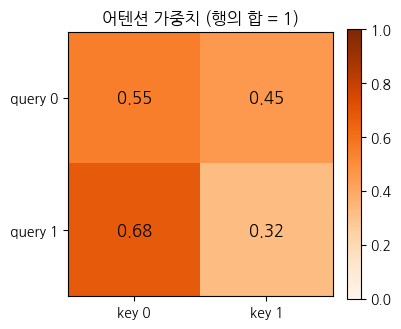

In [9]:
fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(attn, cmap="Oranges", vmin=0, vmax=1)

for (r, c), val in np.ndenumerate(attn):
    ax.text(c, r, f"{val:.2f}", ha="center", va="center", fontsize=12)

ax.set_xticks(range(seq_len))
ax.set_xticklabels([f"key {j}" for j in range(seq_len)])
ax.set_yticks(range(seq_len))
ax.set_yticklabels([f"query {i}" for i in range(seq_len)])
ax.set_title("어텐션 가중치 (행의 합 = 1)")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()


## 4. 연산량(FLOPS) 분석 — 행렬 곱셈은 비용이다

지금까지 우리는 작은 행렬 몇 개를 손으로 계산해 봤습니다. 그런데 실제 LLM(거대 언어모델)은 수십~수백 개의 레이어에서, 수천~수만 차원짜리 행렬 곱셈을 끊임없이 반복합니다. 이때 "이 모델을 한 번 실행하는 데 연산이 도대체 몇 번 필요한가?"를 가늠하는 단위가 **FLOPs(Floating Point Operations, 부동소수점 연산 횟수)**입니다. (참고로 초당 처리량을 말할 때는 보통 대문자 FLOPS로 "초당 연산 횟수"를 뜻하지만, 여기서는 "총 연산 횟수"라는 의미로 사용합니다.)

앞에서 배운 **MAC(곱셈-누산) 1회 = FLOPs 2회**(곱셈 1 + 덧셈 1) 규칙을 그대로 적용해서, 트랜스포머 한 레이어의 어텐션 연산에 필요한 FLOPs를 계산해 보겠습니다. 각 항목은 다음을 의미합니다.

- **QKV 투영**: 입력을 Q, K, V 세 가지로 변환하는 단계. 각각 `(seq_len × d_model) @ (d_model × d_model)` 크기의 행렬 곱셈이 3번(Q, K, V) 필요합니다.
- **Q·K^T**: 우리가 위에서 직접 계산해 본 어텐션 점수 계산. 토큰 수(seq_len)의 **제곱**에 비례한다는 점이 중요합니다 — 문장이 2배 길어지면 이 부분의 연산량은 4배가 됩니다!
- **Attn·V**: 어텐션 가중치와 V를 곱해 최종 출력을 만드는 단계. 역시 seq_len의 제곱에 비례합니다.
- **출력 투영**: 어텐션 결과를 다시 d_model 차원으로 정리하는 단계.

코드의 각 FLOPs 계산식 앞에 곱해진 **2**는 앞서 배운 "MAC 1회 = FLOPs 2회" 규칙에서 온 것이고, **n_heads**가 곱해진 이유는 실제 트랜스포머는 어텐션을 한 번이 아니라 여러 "헤드(head)"로 나누어 병렬로 계산하기 때문입니다(멀티헤드 어텐션, Multi-Head Attention).

아래 코드에서는 교육용 아주 작은 모델, GPT-2 Small, GPT-3 175B 세 가지를 비교해서, 모델이 커질수록 연산량이 얼마나 폭발적으로 늘어나는지 직접 확인해 봅니다.


In [10]:
print("\n\n4. 트랜스포머 연산량 분석")
print("-" * 50)

# (모델 이름, 레이어 수, d_model(임베딩 차원), 헤드 개수, 문장 길이) 순서
configs = [
    ("Tiny (교육용)", 4, 32, 2, 2),
    ("GPT-2 Small", 12, 768, 12, 1024),
    ("GPT-3 175B", 96, 12288, 96, 2048),
]

for name, n_layers, d_model, n_heads, seq_len in configs:
    d_head = d_model // n_heads  # 헤드 하나가 담당하는 차원 수 = 전체 차원을 헤드 개수로 나눈 것

    # 한 레이어의 어텐션 FLOPS
    # 맨 앞의 "2"는 MAC -> FLOPs 변환(곱셈 1 + 덧셈 1)에서 온 것이고,
    # 나머지는 "결과 행렬의 크기 x 내적 한 번의 길이"에서 유도됩니다.
    qkv_flops = 3 * 2 * seq_len * d_model * d_model           # Q, K, V 투영: (seq_len x d_model) @ (d_model x d_model)을 3번
    attn_flops = 2 * n_heads * seq_len * seq_len * d_head     # Q·K^T: 헤드마다 (seq_len x seq_len) 점수, 내적 길이 d_head
    attn_v_flops = 2 * n_heads * seq_len * seq_len * d_head   # Attn·V: 위와 같은 크기, 내적 길이는 seq_len
    out_flops = 2 * seq_len * d_model * d_model                # 출력 투영: (seq_len x d_model) @ (d_model x d_model)

    layer_attn = qkv_flops + attn_flops + attn_v_flops + out_flops
    total = layer_attn * n_layers  # 레이어 하나의 연산량 x 전체 레이어 수

    print(f"\n  {name}:")
    print(f"    QKV 투영:    {qkv_flops:>15,} FLOPS")
    print(f"    Q·K^T:       {attn_flops:>15,} FLOPS")
    print(f"    Attn·V:      {attn_v_flops:>15,} FLOPS")
    print(f"    출력 투영:   {out_flops:>15,} FLOPS")
    print(f"    레이어 총:   {layer_attn:>15,} FLOPS")
    print(f"    전체 ({n_layers}L): {total:>15,} FLOPS ({total/1e12:.2f} TFLOPS)")




4. 트랜스포머 연산량 분석
--------------------------------------------------

  Tiny (교육용):
    QKV 투영:             12,288 FLOPS
    Q·K^T:                   256 FLOPS
    Attn·V:                  256 FLOPS
    출력 투영:             4,096 FLOPS
    레이어 총:            16,896 FLOPS
    전체 (4L):          67,584 FLOPS (0.00 TFLOPS)

  GPT-2 Small:
    QKV 투영:      3,623,878,656 FLOPS
    Q·K^T:         1,610,612,736 FLOPS
    Attn·V:        1,610,612,736 FLOPS
    출력 투영:     1,207,959,552 FLOPS
    레이어 총:     8,053,063,680 FLOPS
    전체 (12L):  96,636,764,160 FLOPS (0.10 TFLOPS)

  GPT-3 175B:
    QKV 투영:    1,855,425,871,872 FLOPS
    Q·K^T:       103,079,215,104 FLOPS
    Attn·V:      103,079,215,104 FLOPS
    출력 투영:   618,475,290,624 FLOPS
    레이어 총:   2,680,059,592,704 FLOPS
    전체 (96L): 257,285,720,899,584 FLOPS (257.29 TFLOPS)


## 정리하며

이 노트북에서 직접 확인한 핵심 아이디어를 정리하면 다음과 같습니다.

1. 행렬 곱셈 `C = A @ B`의 칸 하나(`C[i,j]`)는 **"A의 i번째 행"과 "B의 j번째 열"의 내적**(자리별로 곱한 뒤 모두 더한 값)입니다.
2. 이 내적이 가능하려면 **A의 열 개수와 B의 행 개수가 같아야** 합니다.
3. 행렬 전체를 채우는 것은 위 계산을 **모든 (i, j) 조합에 반복**하는 것뿐입니다.
4. 트랜스포머의 어텐션 점수도 결국 **Query와 Key를 내적**하는 같은 패턴이며, 여기에 스케일링과 소프트맥스가 더해질 뿐입니다.
5. 곱셈 1번 + 덧셈 1번(MAC) = FLOPs 2번이며, 이 단위로 모델의 연산량을 추정할 수 있습니다. 특히 어텐션 연산은 **문장 길이의 제곱**에 비례해서 늘어난다는 점이 중요합니다.

### 직접 해보기 (연습 문제)

아래 문제들은 정답 코드 없이 의도적으로 비워 두었습니다. 위 코드를 복사해서 숫자만 바꿔보며 직접 확인해 보세요.

1. **shape 직접 확인하기**: `A`가 (4, 5) 행렬이고 `B`가 (5, 3) 행렬이라면, `A @ B`의 결과는 몇 행 몇 열일까요? "0-1. 두 행렬은 언제 곱할 수 있을까?" 셀의 `A_demo`, `B_demo`처럼 `np.zeros`로 두 행렬을 만들고 `.shape`을 출력해서 직접 확인해 보세요.
2. **연산량 비교하기**: 4번 섹션의 `configs`에서 `"Tiny (교육용)"`의 `seq_len`을 2에서 8로 바꾸면, `attn_flops`(Q·K^T 연산량)는 몇 배로 늘어날까요? 코드를 실행하기 전에 먼저 손으로 예상해 보고(힌트: Q·K^T는 `seq_len * seq_len`에 비례합니다), 실행 결과와 비교해 보세요.
3. **MAC 횟수 직접 세어보기**: 2번 섹션에서 `total_macs`가 12로 출력되었습니다. `A`가 (2,3), `B`가 (3,2)일 때 "결과 칸 개수(4개) × 내적 한 번에 필요한 곱셈 횟수(3번)"를 직접 곱해서 12가 맞는지 확인해 보세요.
